In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'sysstrat' folder
project_root = Path.cwd()
while not (project_root / "sysstrat").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'sysstrat' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igor\Documents\GitHub\futures_trading_strategies


# Testing EWMAC Forecast Strategy vs Binary MA Crossover

This notebook tests the new risk-scaled `EWMACForecastStrategy` (based on Robert Carver's Systematic Trading framework) against a standard binary `MACrossoverStrategy`. 

We will:
1. Load market data (with a synthetic fallback).
2. Run both strategies through the `VectorizedEngine`.
3. Use the `PortfolioAnalyzer` to compare their performance, correlation, and diversification benefits.
4. Visualize the equity curves and the dynamic position sizing of the forecast strategy.

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from sysstrat import (
    load_simple_price_csv,
    VectorizedEngine,
    PortfolioAnalyzer,
    MACrossoverStrategy,
    EWMACForecastStrategy,
    plot_results,
    plot_backtest_results
)

In [3]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-07-29 13:26:35.893 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-07-29 13:26:35.904 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


## 2. Run Backtests

We will run two strategies:
1. **Binary MA Crossover**: 16/64 EMA, Long/Short mode (always fully invested or short).
2. **EWMAC Forecast**: 16/64 EMA, risk-scaled position sizing based on trend strength and volatility.

In [4]:
# Initialize the vectorized engine
engine = VectorizedEngine(
    initial_capital=100_000,
    commission_per_contract=0.0,  # Adjust if your asset has fixed fees
    slippage_rate=0.0005          # 0.05% slippage
)

results = {}

# Strategy 1: Binary Baseline
print("Running Binary MA Crossover (16/64)...")
strategy_binary = MACrossoverStrategy(
    short_window=16, 
    long_window=64, 
    ma_type='ema', 
    mode='long_short',
    capital=100_000,
    annual_target_risk=0.20,  # Matches the EWMAC strategy
    vol_span=25
)
result_binary = engine.run(strategy_binary, data, strategy_name="Binary_MA_16_64", ticker="MCFTR")
results["Binary_MA_16_64"] = result_binary

# Strategy 2: Risk-Scaled Forecast
print("Running EWMAC Forecast (16/64)...")
strategy_forecast = EWMACForecastStrategy(
    fast_window=16, 
    slow_window=64,
    vol_span=25,
    forecast_scalar=1.9,
    max_forecast=20.0,
    capital=100_000,
    annual_target_risk=0.20
)
result_forecast = engine.run(strategy_forecast, data, strategy_name="EWMAC_Forecast_16_64", ticker="MCFTR")
results["EWMAC_Forecast_16_64"] = result_forecast

print("\n✅ Both backtests completed successfully.")

# Quick look at the binary result
result_binary.print_summary()
result_forecast.print_summary()

Running Binary MA Crossover (16/64)...
Running EWMAC Forecast (16/64)...

✅ Both backtests completed successfully.
┌──────────────────────────────────────────────────────────────────────
│ Strategy: Binary_MA_16_64                          │ MCFTR                    │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +5.4% │
│ Average drawdown                         │                    -2.6% │
│ Maximum drawdown                         │                   -50.5% │
│ Annualised standard deviation            │                    11.4% │
│ Sharpe ratio                             │                     0.47 │
│ Skew                                     │                     0.00 │
│ Lower tail                               │                     1.51 │
│ Upper tail                               │                     1.54 │
└─────────

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


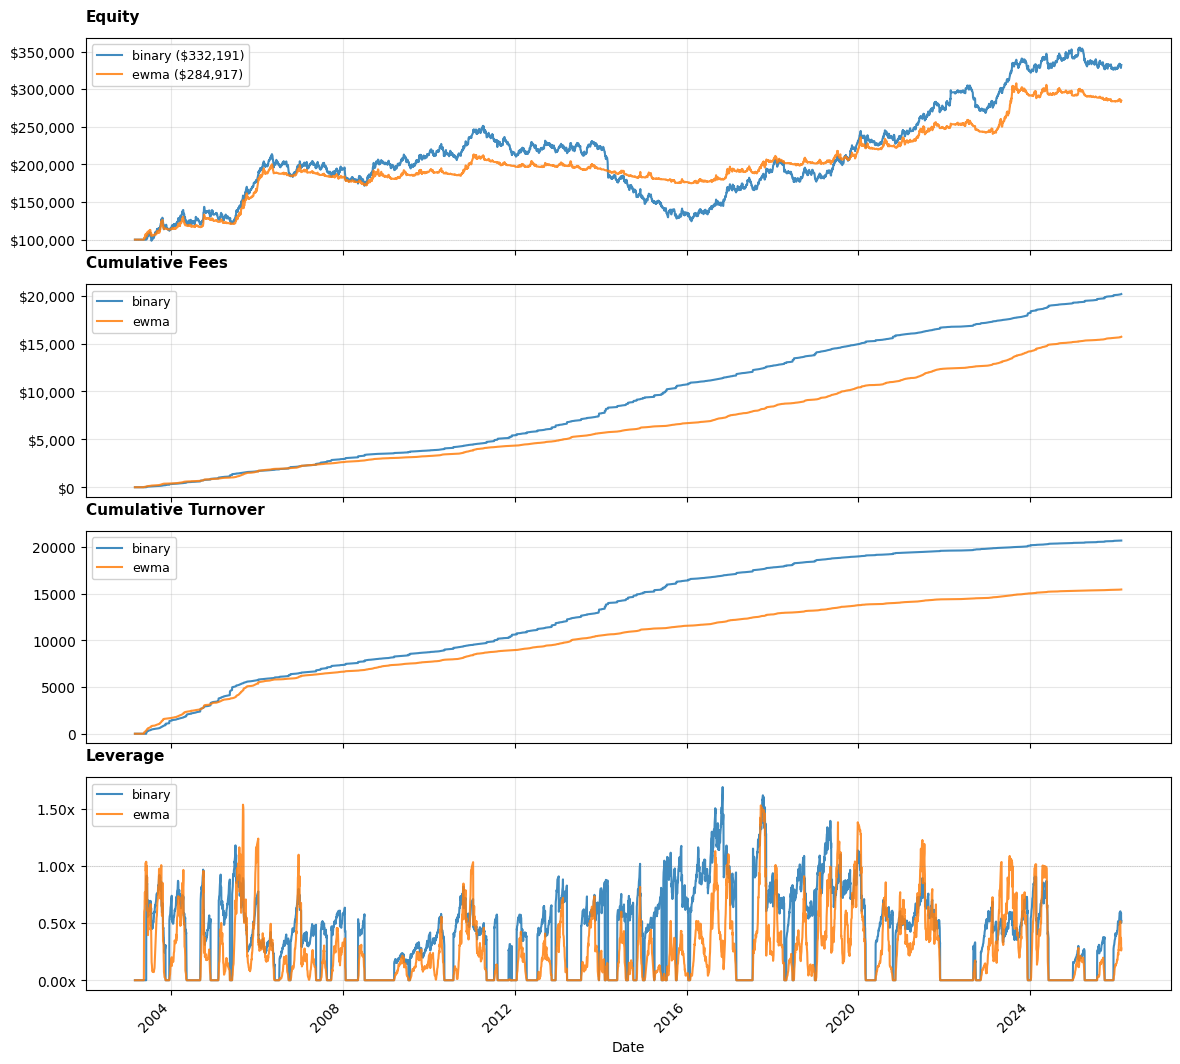

In [5]:
plot_backtest_results(
    results={"binary": result_binary, "ewma": result_forecast},
    panels=['equity', 'cumulative_fees', 'cumulative_turnover', 'leverage'],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)

## 3. Portfolio Analysis & Diversification

Let's combine both strategies into a portfolio (50/50 weight) to see if the risk-scaled strategy provides diversification benefits (e.g., lower correlation, reduced drawdowns) compared to the binary strategy.

In [6]:
# Initialize Portfolio Analyzer
analyzer = PortfolioAnalyzer(
    strategies=results,
    weights=[0.5, 0.5],
    risk_free_rate=0.07
)

# Run analysis
portfolio = analyzer.run()

# Print the comprehensive summary
portfolio.print_summary()

# Show correlation matrix
print("\nStrategy Return Correlation Matrix:")
display(portfolio.correlation_matrix.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format("{:.2f}"))


════════════════════════════════════════════════════════════════════════════════
 PORTFOLIO ANALYSIS SUMMARY
════════════════════════════════════════════════════════════════════════════════

Strategy Allocation:
  Binary_MA_16_64               :   50.0%
  EWMAC_Forecast_16_64          :   50.0%

────────────────────────────────────────────────────────────────────────────────
Portfolio Performance Metrics:
────────────────────────────────────────────────────────────────────────────────
  Total Return                                    +212.02%
  CAGR                                              +5.12%
  Annual Volatility                                  8.95%
  Sharpe Ratio                                       -0.21
  Sortino Ratio                                      -0.29
  Max Drawdown                                     -35.73%
  Gross Sharpe                                        0.60
  Fee Drag Ratio                                      0.08

────────────────────────────────────

,Binary_MA_16_64,EWMAC_Forecast_16_64
Binary_MA_16_64,1.00,0.80
EWMAC_Forecast_16_64,0.80,1.00


In [7]:
comparison_df = portfolio.get_comparison_table()

# Select key columns for a clean display
display_cols = [
    'Strategy', 'Weight', 'cagr_pct', 'annual_volatility_pct', 
    'sharpe_ratio', 'max_drawdown_pct', 'avg_daily_turnover', 'fee_drag_ratio'
]
available_cols = [col for col in display_cols if col in comparison_df.columns]

display_df = comparison_df[available_cols].copy()

# Format for readability
if 'cagr_pct' in display_df.columns:
    display_df['cagr_pct'] = display_df['cagr_pct'].map('{:+.1f}%'.format)
if 'annual_volatility_pct' in display_df.columns:
    display_df['annual_volatility_pct'] = display_df['annual_volatility_pct'].map('{:.1f}%'.format)
if 'sharpe_ratio' in display_df.columns:
    display_df['sharpe_ratio'] = display_df['sharpe_ratio'].map('{:.2f}'.format)
if 'max_drawdown_pct' in display_df.columns:
    display_df['max_drawdown_pct'] = display_df['max_drawdown_pct'].map('{:.1f}%'.format)
if 'Weight' in display_df.columns:
    display_df['Weight'] = display_df['Weight'].map('{:.0%}'.format)
if 'avg_daily_turnover' in display_df.columns:
    display_df['avg_daily_turnover'] = display_df['avg_daily_turnover'].map('{:.2f}'.format)
if 'fee_drag_ratio' in display_df.columns:
    display_df['fee_drag_ratio'] = display_df['fee_drag_ratio'].map('{:.2f}'.format)

display_df.style.set_caption("Strategy vs Portfolio Performance Comparison")

,Strategy,Weight,cagr_pct,annual_volatility_pct,sharpe_ratio,max_drawdown_pct,avg_daily_turnover,fee_drag_ratio
0,Binary_MA_16_64,50%,+5.4%,11.4%,0.47,-50.5%,3.61,0.08
1,EWMAC_Forecast_16_64,50%,+4.7%,7.4%,0.64,-18.0%,2.69,0.08
2,Portfolio,100%,+5.1%,8.9%,-0.21,-35.7%,3.15,0.08
